# Dynamic String Generator

# Bernstein-Vazirani: Dynamic String Generator

**Objective:** Prove the $O(1)$ query complexity of the Bernstein-Vazirani algorithm by dynamically generating and cracking secret strings of arbitrary lengths.

**Theory:**
The true power of Phase Kickback lies in its scalability. Classically, finding a 10-bit string takes 10 queries. Quantumly, finding a 10-bit string takes exactly 1 query. 

In this notebook, we package the Oracle generation and the Hadamard sandwich into a single, scalable pipeline. We can pass a string of any length $n$ into our function, and the simulator will construct the $n+1$ qubit circuit required to solve it instantaneously.

In [1]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from IPython.display import display
import random

print("Environment Ready.")

Environment Ready.


In [2]:
def build_bv_oracle(secret_string: str) -> QuantumCircuit:
    """Dynamically builds a BV Oracle for any length string."""
    n = len(secret_string)
    oracle = QuantumCircuit(n + 1, name="Dynamic_Oracle")
    
    # Reverse string to match Qiskit's endianness
    reversed_string = secret_string[::-1]
    
    for i in range(n):
        if reversed_string[i] == '1':
            oracle.cx(i, n)
            
    return oracle

def run_dynamic_bv(secret_string: str):
    """Builds and executes the full BV algorithm for a given string."""
    n = len(secret_string)
    qc = QuantumCircuit(n + 1, n)
    
    # Initialize output qubit to |1> and apply H to all
    qc.x(n)
    qc.h(range(n + 1))
    qc.barrier()
    
    # Append dynamic Oracle
    oracle = build_bv_oracle(secret_string)
    qc.compose(oracle, inplace=True)
    qc.barrier()
    
    # Interfere and measure
    qc.h(range(n))
    qc.measure(range(n), range(n))
    
    # Execute
    sampler = StatevectorSampler()
    job = sampler.run([qc], shots=1024)
    counts = job.result()[0].data.c.get_counts()
    
    return qc, counts

Target Secret String: 11010110
Required Qubits: 9


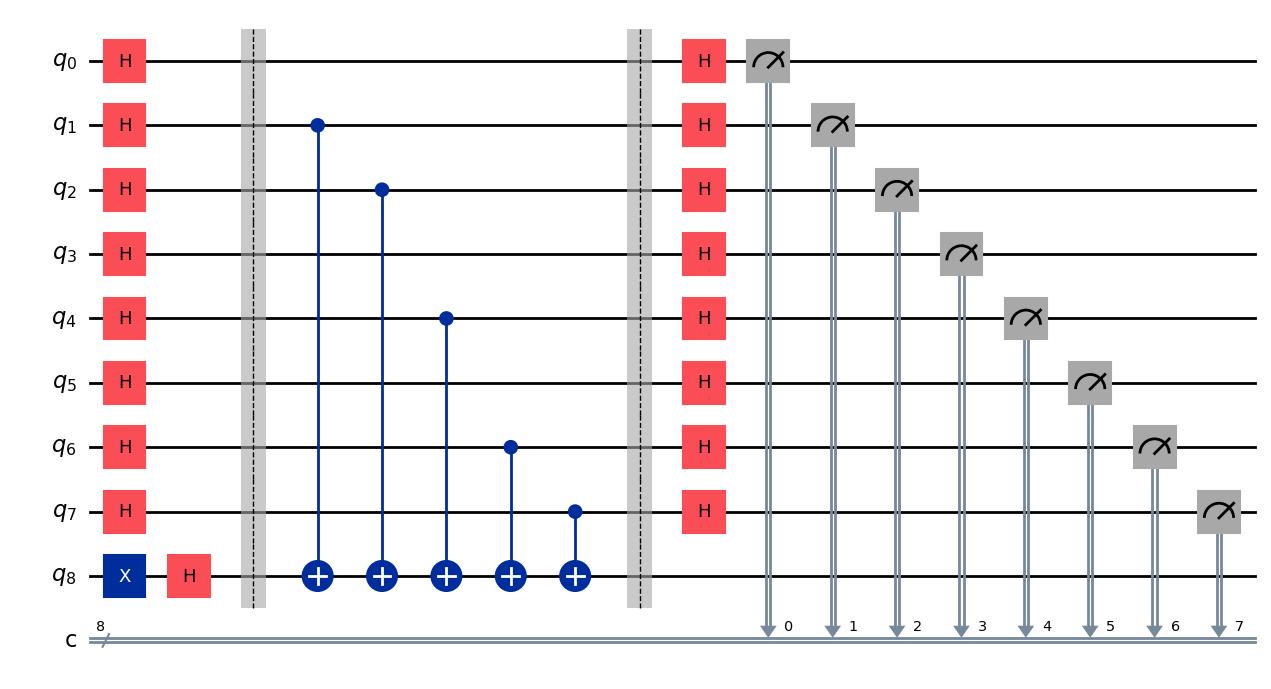

In [3]:
# 1. Define a much longer, arbitrary secret string
dynamic_secret = "11010110"
print(f"Target Secret String: {dynamic_secret}")
print(f"Required Qubits: {len(dynamic_secret) + 1}")

# 2. Run the generalized pipeline
circuit, results = run_dynamic_bv(dynamic_secret)

# 3. Visualize the generated circuit
display(circuit.draw('mpl'))

Measurement Results: {'11010110': 1024}


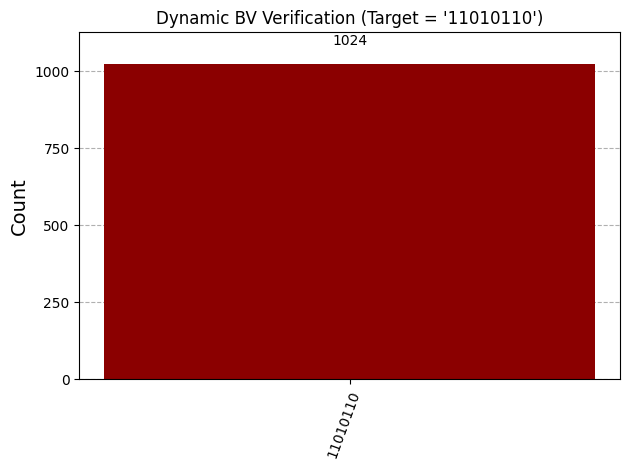

In [4]:
# 4. Verify the output
print(f"Measurement Results: {results}")

# The histogram should show a single bar for our long dynamic string
display(plot_histogram(results, title=f"Dynamic BV Verification (Target = '{dynamic_secret}')", color='darkred'))